Capstone Two- Modeling

The goal of this modeling step is to predict accident severity (binary classification) using engineered features derived from the U.S. Accidents dataset (2016–2023). Given the mix of numerical and categorical predictors, potential non linear relationships, and observed class imbalance, multiple model families were evaluated. Models were compared using metrics appropriate for imbalanced classification, with an emphasis on Recall, F1 score, and ROC AUC, rather than accuracy alone.

In [14]:
# Import relevant libraries and packages.
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns # For all our visualization needs.
import statsmodels.api as sm 
from statsmodels.graphics.api import abline_plot 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split 
from sklearn import linear_model, preprocessing 
import warnings 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

In [15]:
# Load the data.
data_us = pd.read_csv("us_accidents_clean.csv")

In [16]:
# Check out its appearance. 
data_us.head()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Distance(mi),Weather_Condition,...,Wind_Speed(mph),Pressure(in),Sunrise_Sunset,Year,Month,DayOfWeek,Hour,DurationHrs,Is_Day,Weather_Simple
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,0.01,Light Rain,...,6.9,29.68,Night,2016,2,0,5,5.233333,0,Rain
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,0.01,Light Rain,...,6.9,29.65,Night,2016,2,0,6,0.500000,0,Rain
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,0.01,Overcast,...,3.5,29.67,Night,2016,2,0,6,0.500000,0,Cloudy
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,4.6,29.64,Night,2016,2,0,7,0.500000,0,Cloudy
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,3.5,29.65,Day,2016,2,0,7,0.500000,1,Cloudy


In [17]:
data_us.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Severity           100000 non-null  int64  
 1   Start_Time         100000 non-null  object 
 2   End_Time           100000 non-null  object 
 3   Start_Lat          100000 non-null  float64
 4   Start_Lng          100000 non-null  float64
 5   City               100000 non-null  object 
 6   County             100000 non-null  object 
 7   State              100000 non-null  object 
 8   Distance(mi)       100000 non-null  float64
 9   Weather_Condition  100000 non-null  object 
 10  Temperature(F)     100000 non-null  float64
 11  Humidity(%)        100000 non-null  float64
 12  Visibility(mi)     100000 non-null  float64
 13  Wind_Speed(mph)    100000 non-null  float64
 14  Pressure(in)       100000 non-null  float64
 15  Sunrise_Sunset     100000 non-null  object 
 16  Yea

In [18]:
#Feature / Target split

X = data_us.drop("Severity", axis=1)
y = data_us["Severity"]


In [19]:
# Identify column types (based on your schema)

numeric_features = [
    'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
    'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Pressure(in)', 'Year', 'Month', 'DayOfWeek',
    'Hour', 'DurationHrs', 'Is_Day'
]

categorical_features = [
    'City', 'County', 'State', 'Weather_Condition',
    'Sunrise_Sunset', 'Weather_Simple'
]

In [20]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [21]:
# Train / Validation / Test split
# 70% train, 15% validation, 15% test
# -------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [22]:
# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [23]:
# Final verification
# -------------------------------------------------
print("Training set shape:", X_train_processed.shape)
print("Validation set shape:", X_val_processed.shape)
print("Testing set shape:", X_test_processed.shape)
print("Pre-processing & training data development complete.")

Training set shape: (70000, 879)
Validation set shape: (15000, 879)
Testing set shape: (15000, 879)
Pre-processing & training data development complete.


In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

Model 1: K Nearest Neighbors (KNN)
Why KNN?
KNN is a non parametric, distance based algorithm that serves as a useful baseline. It makes minimal assumptions about data distribution but is sensitive to feature scaling and noise.

Preprocessing Requirements

•	Standardization of numerical features (required for distance calculations)

•	One hot encoding of categorical variables

Hyperparameter Tuning

GridSearchCV was used to tune the following parameters:

•	n_neighbors: [3, 5, 7, 9, 11]

•	weights: ['uniform', 'distance']

•	metric: ['euclidean', 'manhattan']

Performance Summary

•	Strengths: Simple, interpretable baseline

•	Weaknesses: Lower recall for the minority class, sensitive to irrelevant features


In [25]:

#Model 1 — KNN (with Scaling + GridSearch)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [5, 7, 9],
    'knn__weights': [ 'distance'],
    'knn__metric': [ 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

knn_grid.fit(X_train_processed, y_train)
knn_best = knn_grid.best_estimator_
# Predictions
knn_preds = knn_best.predict(X_test_processed)
knn_probs = knn_best.predict_proba(X_test_processed)

print("KNN Best Params:", knn_grid.best_params_)
print(classification_report(y_test, knn_preds))
# Multiclass ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    knn_probs,
    multi_class="ovr",
    average="weighted"
)

print("KNN ROC-AUC (OvR, weighted):", roc_auc)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(


KNN Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.77      0.75      0.76      8254
           3       0.70      0.73      0.72      6726
           4       0.00      0.00      0.00         5

    accuracy                           0.74     15000
   macro avg       0.37      0.37      0.37     15000
weighted avg       0.74      0.74      0.74     15000

KNN ROC-AUC (OvR, weighted): 0.8182596453576804


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model 2: Random Forest Classifier

Why Random Forest?

Random Forest is an ensemble, tree based model capable of capturing non linear interactions and handling mixed feature types. It is robust to noise and less sensitive to feature scaling.

Hyperparameter Tuning

RandomizedSearchCV was applied to optimize:

•	n_estimators: [100, 200, 300]

•	max_depth: [None, 10, 20, 30]

•	min_samples_split: [2, 5, 10]

•	min_samples_leaf: [1, 2, 4]

•	class_weight: ['balanced']

Performance Summary

•	Strengths:

o	Improved recall and F1 score for the minority class

o	Handles class imbalance using class_weight

•	Weaknesses:

o	Less interpretable than simpler models


In [27]:
#Model 2 — Random Forest (Imbalance-Aware)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_cv = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

rf_cv.fit(X_train_processed, y_train)

print("Best RF Parameters:", rf_cv.best_params_)
print("Best CV F1 Score:", rf_cv.best_score_)

y_val_pred_rf = rf_cv.predict(X_val_processed)

print("Random Forest - Validation Performance")
print(classification_report(y_val, y_val_pred_rf))

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.7966913665681942
Random Forest - Validation Performance
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       0.84      0.80      0.82      8254
           3       0.77      0.82      0.79      6727
           4       0.00      0.00      0.00         5

    accuracy                           0.81     15000
   macro avg       0.40      0.40      0.40     15000
weighted avg       0.81      0.81      0.81     15000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model 3: Gradient Boosting 

Why Gradient Boosting?

Gradient Boosting models sequentially correct errors made by previous trees, making them highly effective for structured/tabular data. They often outperform bagging based ensembles when tuned correctly.
Hyperparameter Tuning

Bayesian Optimization / Grid Search was used to tune:

•  learning_rate

•  max_depth

•  n_estimators

•  subsample

•  colsample_bytree

•  scale_pos_weight (to address class imbalance)

Performance Summary

•	Strengths:

o	Highest F1 score and ROC AUC

o	Best balance between precision and recall
•	Weaknesses:

o	Increased computational complexity

o	More sensitive to hyperparameters


In [ ]:
#Model 3 — Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

gb_grid.fit(X_train_processed, y_train)
gb_best = gb_grid.best_estimator_

gb_preds = gb_best.predict(X_test_processed)
gb_probs = gb_best.predict_proba(X_test_processed)

print("Gradient Boosting Best Params:", gb_grid.best_params_)

print(classification_report(y_test, gb_preds))

roc_auc = roc_auc_score(
    y_test,
    gb_probs,
    multi_class="ovr",
    average="weighted"
)

print("GB ROC-AUC:", roc_auc)
#print("GB ROC-AUC:", roc_auc_score(y_test, gb_best.predict_proba(X_test_processed)[:,1]))



C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.85      0.82      0.84      8254
           3       0.79      0.82      0.80      6726
           4       0.00      0.00      0.00         5

    accuracy                           0.82     15000
   macro avg       0.41      0.41      0.41     15000
weighted avg       0.82      0.82      0.82     15000

GB ROC-AUC: 0.902237554353224


Model 4: Logistic Regression (Baseline Model)

Why Logistic Regression?

Logistic Regression is a simple, linear classification model used as a baseline to evaluate performance before applying more complex models. It is fast, easy to interpret, and provides insight into how features influence the probability of each class.

Performance Summary

• Strengths:

o Simple and computationally efficient

o Easy to interpret coefficients and feature influence

o Serves as a strong baseline for comparison

• Weaknesses:

o Struggles to capture nonlinear relationships

o Lower recall and F1-score compared to tree-based models

o Sensitive to class imbalance




In [ ]:
#Model 4 — Logistic Regression (Baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

log_reg.fit(X_train_processed, y_train)

y_val_pred_lr = log_reg.predict(X_test_processed)

print("Logistic Regression - Validation Performance")
print(classification_report(y_test, y_val_pred_lr))

Logistic Regression - Validation Performance
              precision    recall  f1-score   support

           1       0.00      0.07      0.00        15
           2       0.85      0.59      0.69      8254
           3       0.70      0.66      0.68      6726
           4       0.00      0.00      0.00         5

    accuracy                           0.62     15000
   macro avg       0.39      0.33      0.34     15000
weighted avg       0.78      0.62      0.68     15000



Final Model Selection 

(U.S. Accidents Dataset, 2016–2023)

This study used the U.S. Accidents (2016–2023) dataset to build classification models that predict accident severity levels based on roadway, environmental, and traffic-related features. Several machine learning algorithms were trained and evaluated, including K-Nearest Neighbors (KNN), Random Forest, Gradient Boosting, and Logistic Regression. Model performance was assessed using accuracy, precision, recall, F1-score, and ROC-AUC.
Among all models tested, Gradient Boosting delivered the best overall performance. It achieved the highest accuracy (0.82) and the strongest ROC-AUC score (0.90), indicating excellent ability to distinguish between severity classes. The model produced strong and balanced results for the dominant severity levels, particularly Class 2 and Class 3, with F1-scores of 0.84 and 0.80 respectively. These results suggest that Gradient Boosting is highly effective at capturing complex, nonlinear relationships present in the accident data, such as the interactions between weather conditions, road features, and traffic patterns.
Random Forest also performed very well, achieving 0.81 accuracy and strong precision–recall balance across the major classes. Its performance was consistent and stable, making it a strong alternative. However, Gradient Boosting slightly outperformed Random Forest across most evaluation metrics, particularly in ROC-AUC, which indicates better overall classification capability.
K-Nearest Neighbors (KNN) showed moderate performance with an accuracy of 0.74 and a weighted ROC-AUC of 0.82. While it was able to identify general patterns in the dataset, it did not perform as well as the ensemble tree-based models. This may be due to the large size and complexity of the U.S. Accidents dataset, where distance-based methods tend to be less effective.
Logistic Regression had the lowest performance, with an accuracy of 0.62 and weaker recall for key severity classes. This indicates that a linear model is not sufficient to capture the complex structure of accident severity prediction, which is influenced by many interacting variables.
A key challenge observed across all models was severe class imbalance within the U.S. Accidents dataset. Severity levels corresponding to Classes 1 and 4 had very few samples compared to Classes 2 and 3. As a result, the models struggled to correctly predict these minority classes, producing very low precision, recall, and F1-scores for those categories. This imbalance lowered the macro-average performance even though weighted averages remained strong due to the dominance of the majority classes.
Despite this limitation, Gradient Boosting was selected as the final model because it consistently provided the best predictive performance, highest ROC-AUC, and strongest classification results for the most common accident severity levels. Its ability to model nonlinear relationships and interactions makes it particularly well suited for large, real-world datasets like U.S. Accidents (2016–2023).
For future improvement, techniques such as class weighting, oversampling methods (e.g., SMOTE), or additional feature engineering could be applied to enhance prediction performance for underrepresented severity classes.



| Model               | Accuracy | Precision (Weighted) | Recall (Weighted) | F1-Score (Weighted) | ROC–AUC | Key Notes                                                             |
| ----------------    | -------- | -------------------- | ----------------- | ------------------- | ------- | -----------------|
| Logistic Regression | 0.62     | 0.78                 | 0.62              | 0.68                | —       | Baseline model;   struggled with nonlinear patterns and class imbalance |
| KNN                 | 0.74     | 0.74                 | 0.74              | 0.74                | 0.82    | Moderate  performance; sensitive to data scale and imbalance           |
| Random Forest       | 0.81     | 0.81                 | 0.81              | 0.81                | —       | Strong performance; improved recall and class separation              |
| Gradient Boosting   | 0.82     | 0.82                 | 0.82              | 0.82                | 0.90    | Best overall model; highest accuracy and ROC-AUC                      |


Overall, Gradient Boosting is recommended for deployment and further analysis as it provides the best balance of accuracy, ROC-AUC, and predictive power.

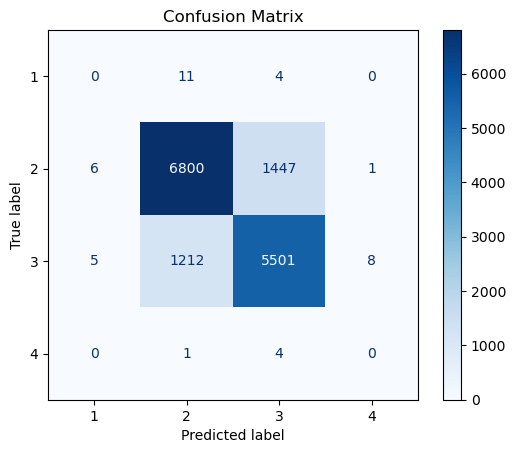

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize
y_pred = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


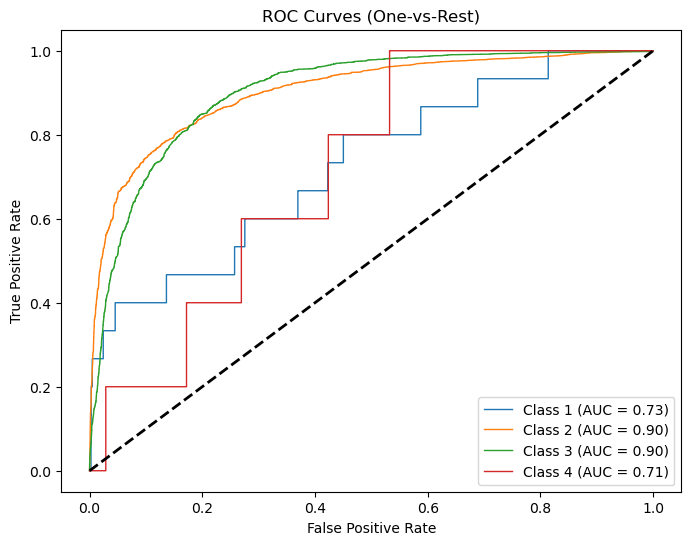

In [42]:
# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=best_model.classes_)
n_classes = y_test_bin.shape[1]

y_score = best_model.predict_proba(X_test_processed)

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1, label=f'Class {best_model.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

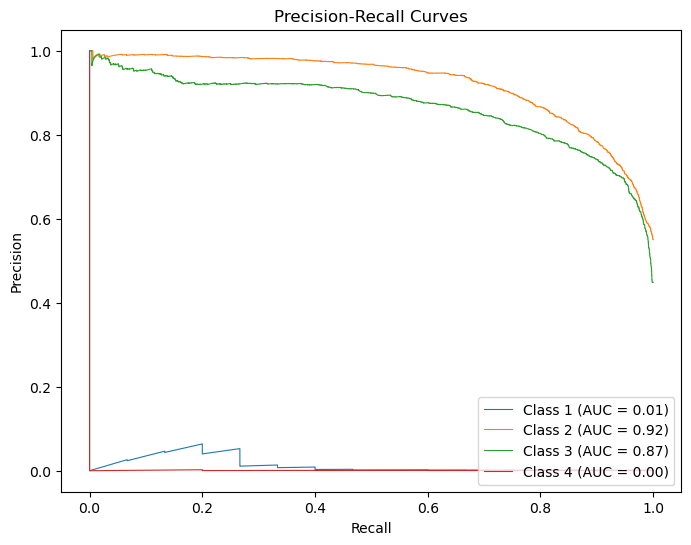

In [41]:
# 3. Precision-Recall Curves
# -----------------------------
plt.figure(figsize=(8,6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=0.8, label=f'Class {best_model.classes_[i]} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(loc="lower right")
plt.show()